# Perceptron

## What Is the Perceptron?

The Perceptron is the simplest possible binary classifier: a single artificial neuron. It takes a vector of inputs, computes a weighted sum, and produces a hard prediction of 0 or 1:

$$\hat{y} = \begin{cases} 1 & \text{if } \mathbf{w} \cdot \mathbf{x} + b \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

The algorithm sees one sample at a time. If the prediction is correct, nothing changes. If it is wrong, the weight vector is nudged in the direction that would have produced the right answer:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta(y - \hat{y})\mathbf{x}$$

## 1. Setup & Data Download

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import urllib.request, os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.perceptron import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'diabetes.csv'
if not os.path.exists(CSV_PATH):
    url = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
           'pima-indians-diabetes.data.csv')
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset already present.


## 2. Data Exploration

In [24]:
col_names = ['pregnancies','glucose','blood_pressure','skin_thickness',
             'insulin','bmi','diabetes_pedigree','age','outcome']
df = pd.read_csv(CSV_PATH, header=None, names=col_names)
feature_cols = col_names[:-1]

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['outcome'].value_counts().rename({0:'No Diabetes', 1:'Diabetes'}))
print(f'\nPositive rate: {df["outcome"].mean():.3f}')
df.describe()

Shape: (768, 9)

Class distribution:
outcome
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Positive rate: 0.349


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


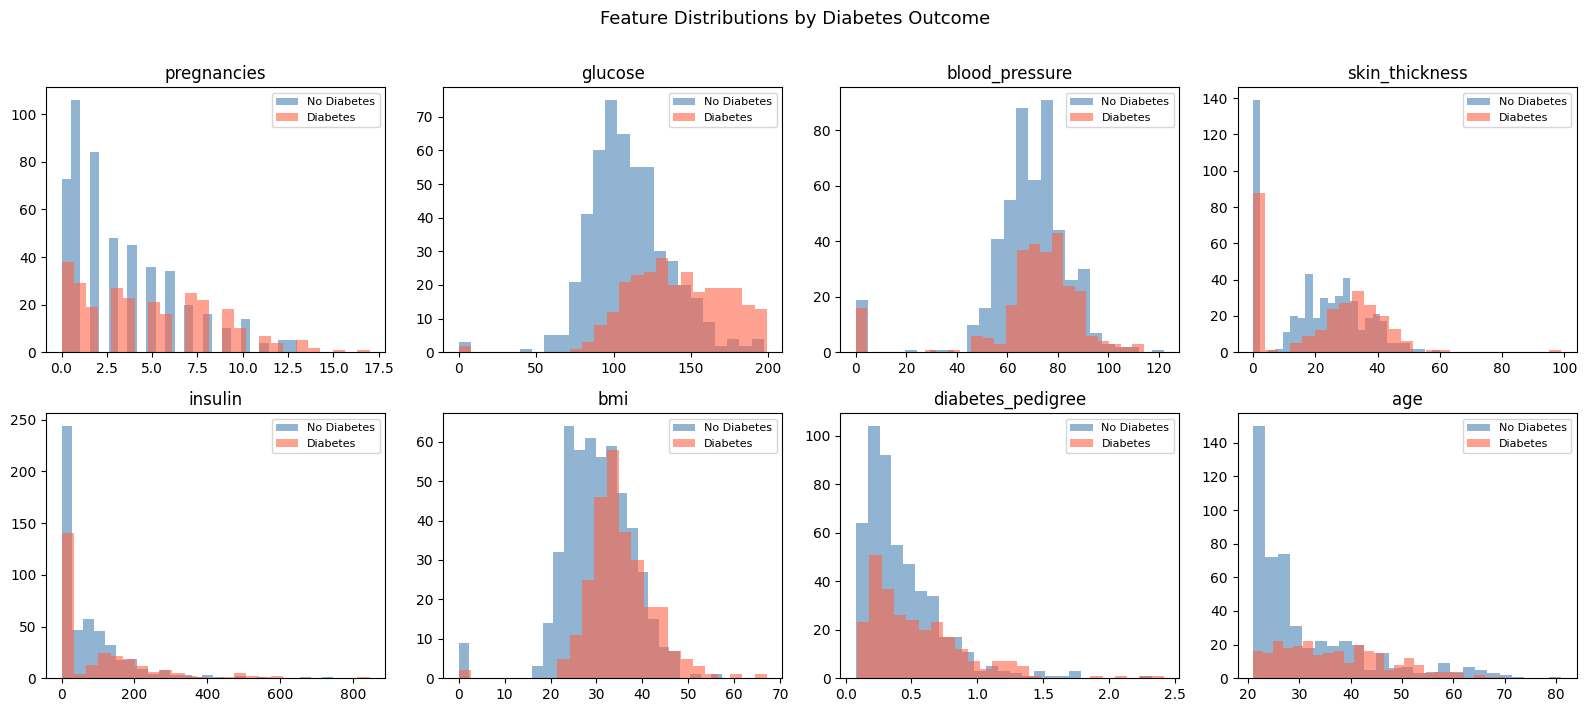

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Diabetes', 1: 'Diabetes'}

for ax, col in zip(axes.flat, feature_cols):
    for cls in [0, 1]:
        ax.hist(df[df['outcome'] == cls][col], bins=25,
                alpha=0.6, color=colors[cls], label=labels[cls])
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Each panel above shows one feature's distribution split by class (blue=no diabetes, red=diabetes).

- 'glucose' seems to be the better separator. Diabetic patients skew toward higher glucose. The Perceptron will likely assign a large weight to this feature.
- 'bmi' and 'age' show a moderate overlap. Diabetic patients tend to be older and heavier, but many exceptions exist. These features add signal but not clean separation.
- 'insulin' and 'skin_thickness' show heavy overlap with many zero values (missing data is recorded as 0). These features are noisy and may hurt more than help.

Overall, no single feature cleanly separates the classes. The two distributions overlap substantially in every panel, confirming the data is not  perfectly linearly separable. The Perceptron will not reach zero errors.

## 3. Preprocessing

The Perceptron computes dot products between weights and features. `insulin` ranges up to 846 while `diabetes_pedigree` is in [0, 2.4]. Without scaling, insulin would completely dominate every weight update. **StandardScaler** fixes this by making every feature zero-mean and unit-variance.

In [26]:
X = df[feature_cols].values
y = df['outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)  # transform only, never fit on test

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'Positive rate — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')

Train: (614, 8)  |  Test: (154, 8)
Positive rate — train: 0.349  test: 0.351


## 4. Training

In [27]:
model = Perceptron(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_s, y_train)

print(f'Train accuracy : {model.score(X_train_s, y_train):.4f}')
print(f'Test  accuracy : {model.score(X_test_s, y_test):.4f}')
print(f'Epochs run     : {len(model.errors_per_epoch)}')
print(f'Final epoch errors: {model.errors_per_epoch[-1]}')

Train accuracy : 0.7296
Test  accuracy : 0.6753
Epochs run     : 1000
Final epoch errors: 194


## 5. Convergence Curve — Non-Separable Data

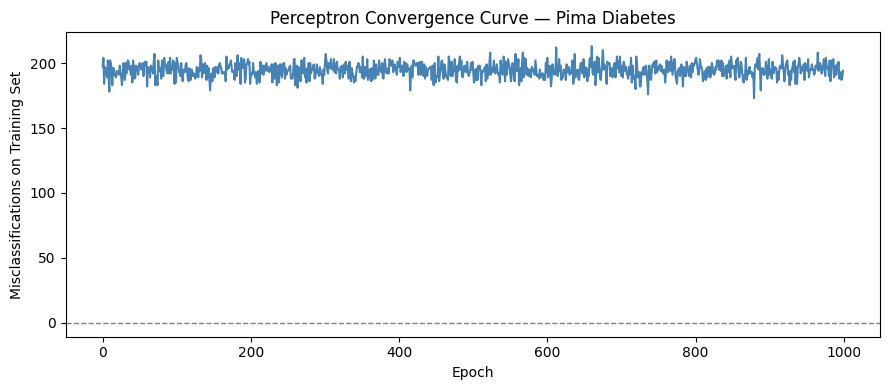

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.errors_per_epoch, color='steelblue', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('Misclassifications on Training Set')
ax.set_title('Perceptron Convergence Curve — Pima Diabetes')
plt.tight_layout()
plt.show()

The error curve above does not show a smooth downward trend. Instead, it fluctuates around a relatively constant value. This reflects the fact that the dataset is not linearly separable.

The Perceptron continually updates its decision boundary, improving classification for some samples while worsening it for others. Because no single linear boundary can separate the classes, the algorithm never stabilizes and does not converge to a lower error region.

This oscillatory behavior is a defining limitation of the Perceptron on real-world data and motivates the need for more flexible models such as logistic regression or multilayer neural networks.

## 6. Scaled vs Unscaled

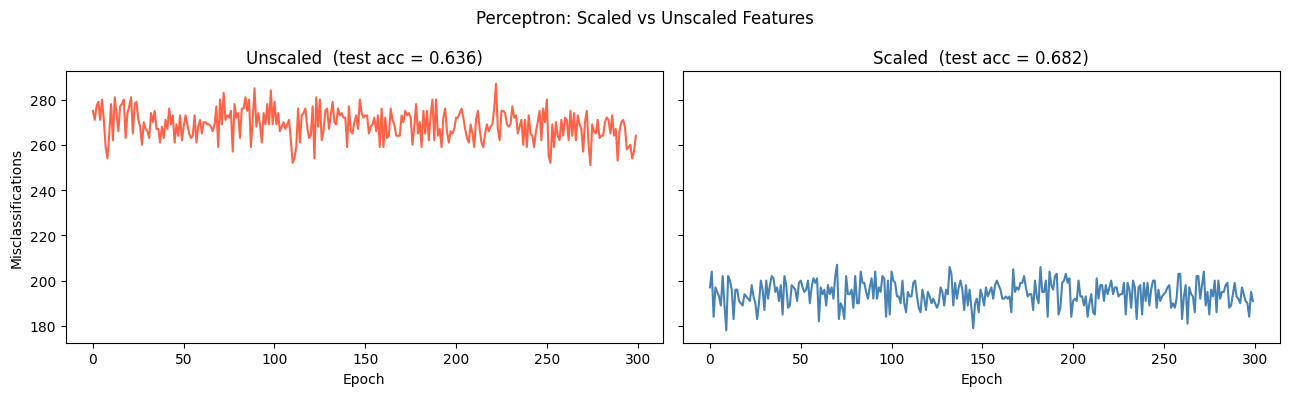

In [32]:
model_unscaled = Perceptron(learning_rate=0.01, n_iterations=300)
model_unscaled.fit(X_train, y_train)  # raw features

model_scaled = Perceptron(learning_rate=0.01, n_iterations=300)
model_scaled.fit(X_train_s, y_train)  # standardized features

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(model_unscaled.errors_per_epoch, color='tomato', linewidth=1.5)
axes[0].set_title(f'Unscaled  (test acc = {model_unscaled.score(X_test, y_test):.3f})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Misclassifications')

axes[1].plot(model_scaled.errors_per_epoch, color='steelblue', linewidth=1.5)
axes[1].set_title(f'Scaled  (test acc = {model_scaled.score(X_test_s, y_test):.3f})')
axes[1].set_xlabel('Epoch')

plt.suptitle('Perceptron: Scaled vs Unscaled Features', fontsize=12)
plt.tight_layout()
plt.show()

Left plot (unscaled): the curve is erratic and slow to descend. Features like 'insulin' (range 0–846) produce enormous gradient steps that destabilize the weight vector. Low-magnitude features like 'diabetes_pedigree' (range 0–2.4) are effectively ignored.

Right plot (scaled): the curve descends more smoothly and stabilizes faster. All features contribute proportionally to each update because they share the same scale after StandardScaler.

The test accuracy difference quantifies the cost of skipping standardization. It is not optional for any distance or dot-product-based algorithm.

## 7. Learned Weights

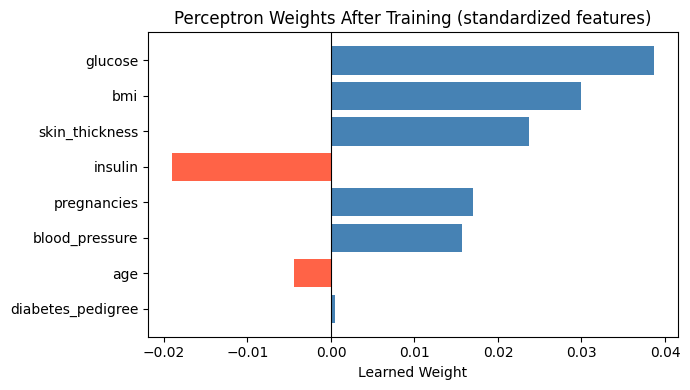

In [33]:
order = np.argsort(np.abs(model.weights))
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['tomato' if w < 0 else 'steelblue' for w in model.weights[order]]
ax.barh([feature_cols[i] for i in order], model.weights[order], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Learned Weight')
ax.set_title('Perceptron Weights After Training (standardized features)')
plt.tight_layout()
plt.show()

Each bar in the graph above is the weight the Perceptron assigned to that feature after training.

Because features are standardized, weights are on a comparable scale: larger absolute weight = that feature was more useful for separating the classes.

- Blue bars (positive weight): higher values push toward predicting diabetes (1).
- Red bars (negative weight): higher values push toward predicting no diabetes (0).  

- 'glucose' was assigned the largest weight, which is consistent with the histogram analysis in Section 2, where glucose showed the clearest class separation compared to other parameters.
- 'bmi' and 'age' usually have moderate positive weights.
- Features with noisy distributions (insulin, skin_thickness) may get small or even counter-intuitive weights.

These weights reflect a linear model's best attempt at separating non-linearly separable classes. They are informative but not fully reliable as feature importance scores.

## 8. Learning Rate Comparison

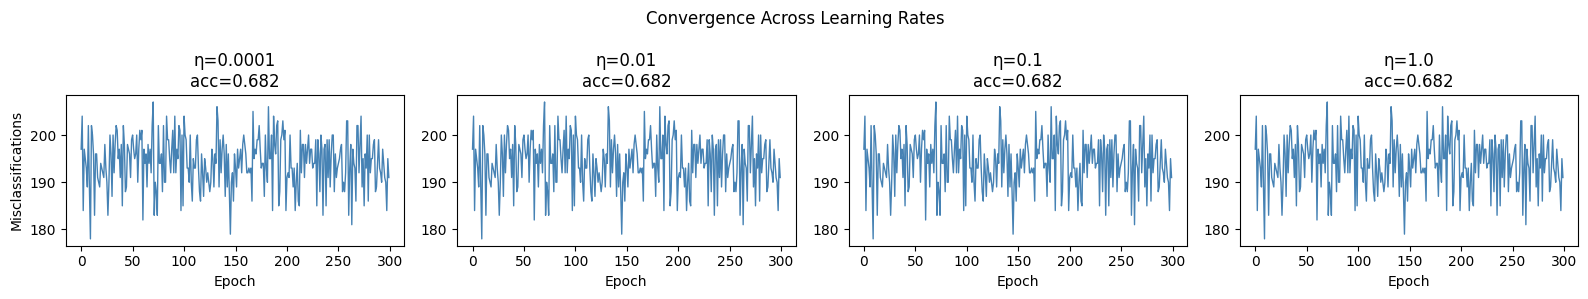

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
lrs = [0.0001, 0.01, 0.1, 1.0]

for ax, lr in zip(axes, lrs):
    m = Perceptron(learning_rate=lr, n_iterations=300)
    m.fit(X_train_s, y_train)
    acc = m.score(X_test_s, y_test)
    ax.plot(m.errors_per_epoch, color='steelblue', linewidth=1)
    ax.set_title(f'η={lr}\nacc={acc:.3f}')
    ax.set_xlabel('Epoch')
    if ax is axes[0]:
        ax.set_ylabel('Misclassifications')

plt.suptitle('Convergence Across Learning Rates', fontsize=12)
plt.tight_layout()
plt.show()

All learning rates produce very similar convergence behavior. The error curves fluctuate around the same level, and the final accuracy is identical across all values of η.

This happens because the dataset is not linearly separable, so the Perceptron cannot converge to a stable solution regardless of step size. Instead of steadily decreasing, the algorithm continually adjusts the decision boundary, improving some classifications while worsening others.

As a result, the learning rate has limited impact: it changes the magnitude of updates, but not the fundamental limitation of the model. The dominant factor here is the linear nature of the Perceptron, not the optimization dynamics.

## 9. Evaluation

              precision    recall  f1-score   support

 No Diabetes       0.76      0.74      0.75       100
    Diabetes       0.54      0.56      0.55        54

    accuracy                           0.68       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.68      0.68       154



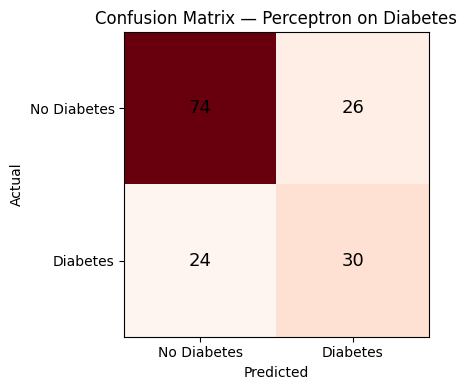

In [35]:
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Reds')
ax.set_xticks([0,1]); ax.set_xticklabels(['No Diabetes','Diabetes'])
ax.set_yticks([0,1]); ax.set_yticklabels(['No Diabetes','Diabetes'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Perceptron on Diabetes')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=13)
plt.tight_layout(); plt.show()

- Top-left  (TN): correctly predicted no diabetes.
- Bottom-right (TP): correctly predicted diabetes.
- Bottom-left (FN): missed diabetics (predicted healthy when they had diabetes).
- Top-right  (FP): false alarms (predicted diabetes when actually healthy).

In clinical screening, False Negatives are the dangerous errors since a missed diagnosis means a patient goes untreated. The Perceptron's linear boundary
cannot achieve low FN rates here because the classes genuinely overlap.
A Logistic Regression (which outputs probabilities) or MLP (non-linear boundary) would allow threshold tuning to reduce FN at the cost of more FP.

## 10. Key Takeaways

- The convergence curve **not reaching zero** is not a failure, it is the correct behavior on non-linearly separable data. The Perceptron Convergence Theorem only guarantees convergence when perfect separation exists.
- **Standardization has a measurable accuracy impact** on this dataset: the scaled vs unscaled comparison shows the real cost of skipping it.
- **Learned weights on standardized features** give a rough feature importance ranking: glucose dominates, followed by BMI and age.
- The Perceptron's hard linear boundary is its ceiling, it cannot improve further regardless of iterations. This motivates the **Multilayer Perceptron (MLP)**, which stacks non-linear layers to learn curved decision boundaries.

## Why Perceptron?

This dataset is a natural fit for the Perceptron because:

- **Binary target**: diabetic (1) vs non-diabetic (0), which is exactly what the kind of target the Perceptron is designed for.
- **Purely numerical features** (no encoding needed): glucose level, BMI, blood pressure, age, insulin, etc. All features are on different scales, which makes standardization effects immediately visible and measurable.
- **Moderate separability**: the two classes are not perfectly linearly separable, which is intentional. It shows what happens when the Convergence Theorem's condition is *not* fully met, and demonstrates the value of the iteration limit and early stopping on `errors_per_epoch`.
- **8 features**. The dataset is rich enough to explore weight magnitudes and compare their influence, but small enough that each training step is fast and traceable.